# Validation of Low Pileup Pilot


In [51]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import uproot
import sys
import time
from tqdm import tqdm
from pathlib import Path
import atlasify as atl
atl.ATLAS = "ColliderML"

sys.path.append("../")
from edm4hep_utils import load_edm4hep_file

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Roadmap

1. Load track candidates from ckf and ambi from an event
2. Inspect first total number of particles in event that are >1 GeV, primary, non-electron, leave a hit = "target particles"
3. Inspect number of track candidates, and their fits

## Inspect

In [52]:
ckf_tracks_file = "/global/cfs/projectdirs/m3443/usr/dtmurnane/Side_Work/ACTS/outputs/low_pileup_pilot/gg2ttbar/v1/runs/0/tracksummary_ckf.root"
ambi_tracks_file = "/global/cfs/projectdirs/m3443/usr/dtmurnane/Side_Work/ACTS/outputs/low_pileup_pilot/gg2ttbar/v1/runs/0/tracksummary_ambi.root"

ambi_performance_finding_file = "/global/cfs/projectdirs/m3443/usr/dtmurnane/Side_Work/ACTS/outputs/low_pileup_pilot/gg2ttbar/v1/runs/0/performance_finding_ambi.root"
ambi_performance_fitting_file = "/global/cfs/projectdirs/m3443/usr/dtmurnane/Side_Work/ACTS/outputs/low_pileup_pilot/gg2ttbar/v1/runs/0/performance_fitting_ambi.root"

ckf_performance_finding_file = "/global/cfs/projectdirs/m3443/usr/dtmurnane/Side_Work/ACTS/outputs/low_pileup_pilot/gg2ttbar/v1/runs/0/performance_finding_ckf.root"
ckf_performance_fitting_file = "/global/cfs/projectdirs/m3443/usr/dtmurnane/Side_Work/ACTS/outputs/low_pileup_pilot/gg2ttbar/v1/runs/0/performance_fitting_ckf.root"

edm4hep_file = "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/outputs/low_pileup_pilot/gg2ttbar/v1/runs/0/edm4hep.root"
particles_file = "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/outputs/low_pileup_pilot/gg2ttbar/v1/runs/0/particles.root"
hits_file = "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/outputs/low_pileup_pilot/gg2ttbar/v1/runs/0/simhits.root"
measurements_file = "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/outputs/low_pileup_pilot/gg2ttbar/v1/runs/0/measurements.root"

In [53]:
ckf_tracks = uproot.open(ckf_tracks_file)["tracksummary"]
ambi_tracks = uproot.open(ambi_tracks_file)["tracksummary"]

ckf_tracks.show(), ambi_tracks.show()


name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
event_nr             | uint32_t                 | AsDtype('>u4')
track_nr             | std::vector<uint32_t>    | AsJagged(AsDtype('>u4'), he...
nStates              | std::vector<uint32_t>    | AsJagged(AsDtype('>u4'), he...
nMeasurements        | std::vector<uint32_t>    | AsJagged(AsDtype('>u4'), he...
nOutliers            | std::vector<uint32_t>    | AsJagged(AsDtype('>u4'), he...
nHoles               | std::vector<uint32_t>    | AsJagged(AsDtype('>u4'), he...
nSharedHits          | std::vector<uint32_t>    | AsJagged(AsDtype('>u4'), he...
chi2Sum              | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
NDF                  | std::vector<uint32_t>    | AsJagged(AsDtype('>u4'), he...
measurementChi2      | std::vector<std::vect... | AsObjects(AsVector(True, As...
outlierChi2          | std::vector<std::vect

(None, None)

In [54]:
ambi_performance_finding = uproot.open(ambi_performance_finding_file)
ambi_performance_fitting = uproot.open(ambi_performance_fitting_file)

ckf_performance_finding = uproot.open(ckf_performance_finding_file)
ckf_performance_fitting = uproot.open(ckf_performance_fitting_file)

ambi_performance_finding.keys(), ambi_performance_fitting.keys(), ckf_performance_finding.keys(), ckf_performance_fitting.keys()


(['trackeff_vs_pT;1',
  'trackeff_vs_eta;1',
  'trackeff_vs_phi;1',
  'trackeff_vs_z0;1',
  'trackeff_vs_DeltaR;1',
  'nRecoTracks_vs_pT;1',
  'nTruthMatchedTracks_vs_pT;1',
  'nFakeTracks_vs_pT;1',
  'nRecoTracks_vs_eta;1',
  'nTruthMatchedTracks_vs_eta;1',
  'nFakeTracks_vs_eta;1',
  'fakerate_vs_pT;1',
  'fakerate_vs_eta;1',
  'fakerate_vs_phi;1',
  'duplicationRate_vs_pT;1',
  'duplicationRate_vs_eta;1',
  'duplicationRate_vs_phi;1',
  'nDuplicated_vs_pT;1',
  'nDuplicated_vs_eta;1',
  'nDuplicated_vs_phi;1',
  'nStates_vs_eta;1',
  'nMeasurements_vs_eta;1',
  'nOutliers_vs_eta;1',
  'nHoles_vs_eta;1',
  'nSharedHits_vs_eta;1',
  'nStates_vs_pT;1',
  'nMeasurements_vs_pT;1',
  'nOutliers_vs_pT;1',
  'nHoles_vs_pT;1',
  'nSharedHits_vs_pT;1',
  'eff_tracks;1',
  'fakerate_tracks;1',
  'duplicaterate_tracks;1',
  'eff_particles;1',
  'fakerate_particles;1',
  'duplicaterate_particles;1'],
 ['res_d0;1',
  'res_d0_vs_eta;1',
  'resmean_d0_vs_eta;1',
  'reswidth_d0_vs_eta;1',
  'res_d0_

In [55]:
event = load_edm4hep_file(edm4hep_file, 0)
edm_particles = event["particles_df"]

Convert all values to dataframes

In [56]:
from utils import load_root_file

In [57]:
particles_df = load_root_file(particles_file)
particles_df = particles_df[particles_df.event_id == 0]

hits_df = load_root_file(hits_file)
hits_df = hits_df[hits_df.event_id == 0]

measurements_df = load_root_file(measurements_file)
measurements_df = measurements_df[measurements_df.event_nr == 0]


In [58]:
measurements_df.columns

Index(['event_nr', 'volume_id', 'layer_id', 'surface_id', 'rec_loc0',
       'rec_loc1', 'rec_time', 'var_loc0', 'var_loc1', 'var_time', 'clus_size',
       'clus_size_loc0', 'clus_size_loc1', 'true_loc0', 'true_loc1',
       'true_phi', 'true_theta', 'true_qop', 'true_time', 'true_x', 'true_y',
       'true_z', 'true_incident_phi', 'true_incident_theta', 'residual_loc0',
       'residual_loc1', 'residual_time', 'pull_loc0', 'pull_loc1',
       'pull_time'],
      dtype='object')

In [59]:
measurements_df

,event_nr,volume_id,layer_id,surface_id,rec_loc0,rec_loc1,rec_time,var_loc0,var_loc1,var_time,...,true_y,true_z,true_incident_phi,true_incident_theta,residual_loc0,residual_loc1,residual_time,pull_loc0,pull_loc1,pull_time
entry,,,,,,,,,,,,,,,,,,,,,
0,0,16,4,1,-5.409122,13.312438,2162.353027,0.000225,0.000225,625.0,...,5.393176,-1515.599976,-1.459599,-1.473839,-0.015946,-0.014301,-13.729248,-1.063093,-0.953420,-0.549170
1,0,16,4,1,-4.632894,-12.995185,1821.558716,0.000225,0.000225,625.0,...,4.650855,-1515.599976,-1.572250,-1.527913,0.017961,-0.020838,-1.549194,1.197370,-1.389186,-0.061968
2,0,16,4,1,1.787813,14.187524,5406.177246,0.000225,0.000225,625.0,...,-1.796745,-1515.599976,-1.520368,-1.362961,-0.008933,0.033748,-11.011230,-0.595514,2.249845,-0.440449
3,0,16,4,1,-4.117750,-33.291126,5442.849609,0.000225,0.000225,625.0,...,4.109626,-1515.599976,-1.750785,-1.376686,-0.008124,0.007000,14.190918,-0.541592,0.466665,0.567637
4,0,16,4,1,8.636145,-26.361797,3883.422119,0.000225,0.000225,625.0,...,-8.630102,-1515.599976,-1.565840,-1.535524,0.006042,0.025846,46.334961,0.402832,1.723099,1.853398
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22060,0,30,12,188,35.540771,NaN,NaN,0.005184,NaN,NaN,...,778.393188,3009.500000,1.726234,0.873742,-0.051121,NaN,NaN,-0.710011,NaN,NaN
22061,0,30,12,188,34.958580,NaN,NaN,0.005184,NaN,NaN,...,798.362793,3009.543213,0.879723,0.909441,0.000969,NaN,NaN,0.013457,NaN,NaN
22062,0,30,12,189,-14.156915,NaN,NaN,0.005184,NaN,NaN,...,826.348511,3025.500000,-0.974864,-2.480016,0.094078,NaN,NaN,1.306640,NaN,NaN


In [60]:
hits_df

,event_id,geometry_id,particle_id,tx,ty,tz,tt,tpx,tpy,tpz,...,deltapx,deltapy,deltapz,deltae,index,volume_id,boundary_id,layer_id,approach_id,sensitive_id
entry,,,,,,,,,,,,,,,,,,,,,
0,0,1152921779484754177,5874690761757029,89.326736,5.393176,-1515.599976,2176.082275,0.249235,-0.286123,-2.562505,...,0.0,0.0,0.0,-0.000048,-1,16,0,4,0,1
1,0,1152921779484754177,6139673098346907,63.025654,4.650855,-1515.599976,1823.107910,0.516405,0.017491,-12.034775,...,0.0,0.0,0.0,-0.000034,-1,16,0,4,0,1
2,0,1152921779484754177,5765839279405280,90.153778,-1.796745,-1515.599976,5417.188477,0.013453,-0.003220,-0.063792,...,0.0,0.0,0.0,-0.000039,-1,16,0,4,0,1
3,0,1152921779484754177,5917571883897299,42.701874,4.109626,-1515.599976,5428.658691,0.008908,0.008245,-0.045315,...,0.0,0.0,0.0,-0.000047,-1,16,0,4,0,1
4,0,1152921779484754177,5348024591875968,49.612358,-8.630102,-1515.599976,3837.087158,0.394229,-0.055370,-11.171949,...,0.0,0.0,0.0,-0.000031,-1,16,0,4,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22060,0,2161728645771607042,8172670165793608,641.695312,778.393188,3009.500000,1461.297974,0.000915,0.001897,0.002473,...,0.0,0.0,0.0,-0.000085,-1,30,0,12,0,188
22061,0,2161728645771607042,6167161023350923,655.605896,798.362793,3009.543213,8740.767578,0.000030,0.000004,0.000027,...,0.0,0.0,0.0,-0.000002,-1,30,0,12,0,188
22062,0,2161728645771607298,7068760557851021,494.181335,826.348511,3025.500000,7913.167480,-0.032335,-0.021248,0.026641,...,0.0,0.0,0.0,-0.000980,-1,30,0,12,0,189


In [61]:
measurements_df[["true_x", "true_y", "true_z"]].sort_values("true_z")

,true_x,true_y,true_z
entry,,,
16840,-114.974174,963.678467,-3025.625000
16839,-114.983482,963.767151,-3025.613281
16868,-1021.349854,145.476547,-3025.593262
16930,686.831238,816.056152,-3025.592529
16869,-1021.338684,145.488861,-3025.571045
...,...,...,...
21972,960.913391,309.002258,3025.580566
22056,745.627136,706.365479,3025.584717
22002,-951.832458,-263.780640,3025.605957


In [62]:
hits_df[["tx", "ty", "tz", "te"]].sort_values("tz")

,tx,ty,tz,te
entry,,,,
16840,-114.974174,963.678467,-3025.625000,0.938272
16839,-114.983482,963.767151,-3025.613281,0.938915
16868,-1021.349854,145.476547,-3025.593262,0.000512
16930,686.831238,816.056152,-3025.592529,0.000630
16869,-1021.338684,145.488861,-3025.571045,0.000511
...,...,...,...,...
21972,960.913391,309.002258,3025.580566,0.000102
22056,745.627136,706.365479,3025.584717,0.938917
22002,-951.832458,-263.780640,3025.605957,0.000553


In [63]:
hit_counts = hits_df.groupby("particle_id").size()
hit_counts_df = hit_counts.reset_index(name='n_hits')

# Merge with particles DataFrame
particles_df = particles_df.merge(
    hit_counts_df, 
    how='left', 
    on='particle_id'
).fillna(0)  # Particles with no hits get 0

In [64]:
particles_df

,event_id,particle_id,particle_type,process,vx,vy,vz,vt,px,py,...,vertex_secondary,particle,generation,sub_particle,e_loss,total_x0,total_l0,number_of_hits,outcome,n_hits
0,0,4504699155841029,-2,0,0.003543,-0.005813,-105.372108,2425.787842,-3.244334,1.407285,...,1,1,1,5,12.115084,0.0,0.0,0,0,0.0
1,0,4504699155841032,-1,0,0.003543,-0.005813,-105.372108,2425.787842,-2.774586,-0.292908,...,1,1,1,8,12.869830,0.0,0.0,0,0,0.0
2,0,4542082569470722,-211,0,0.003543,-0.005813,-105.372108,2425.787842,1.175650,0.272212,...,35,2,24,770,2.083743,0.0,0.0,0,0,13.0
3,0,4592660372048331,211,0,0.009781,0.014497,-116.807983,3995.353760,-0.969926,-0.885298,...,81,18,12,51659,5.592474,0.0,0.0,0,0,10.0
4,0,4621247405833537,3,0,0.003543,-0.005813,-105.372108,2425.787842,-1.653649,-0.264909,...,107,2,11,15681,1.554827,0.0,0.0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323,0,8988507592132378,-2212,0,0.003543,-0.005813,-105.372108,2425.787842,3.789078,-0.840354,...,4079,2,23,1818,37.361057,0.0,0.0,0,0,2.0
324,0,8988507592132379,213,0,0.003543,-0.005813,-105.372108,2425.787842,6.949781,-1.863585,...,4079,2,23,1819,68.278442,0.0,0.0,0,0,0.0
325,0,8989607103824618,11,0,0.643046,-0.055682,-106.382172,2427.019775,3.200787,-0.905479,...,4080,2,24,746,7.821862,0.0,0.0,0,0,16.0
326,0,9001701731864898,-321,0,1.826368,0.111195,-107.663475,2428.814453,3.066757,0.326555,...,4091,2,26,4418,4.048696,0.0,0.0,0,0,15.0


<Axes: xlabel='pt', ylabel='Count'>

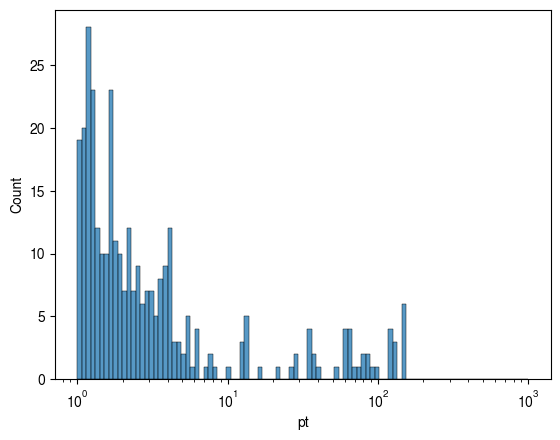

In [65]:
sns.histplot(particles_df.pt, bins=100, binrange=(0, 3), log_scale=True)

In [66]:
particles_df.pt.describe()

count    328.000000
mean      12.495317
std       30.033005
min        1.004212
25%        1.298688
50%        1.978028
75%        4.031427
max      146.133087
Name: pt, dtype: float64

In [67]:
edm_particles.pt.describe()

count    406505.000000
mean          0.053122
std           1.062443
min           0.000000
25%           0.001078
50%           0.001906
75%           0.004448
max         151.577713
Name: pt, dtype: float64

<Axes: xlabel='pt', ylabel='Count'>

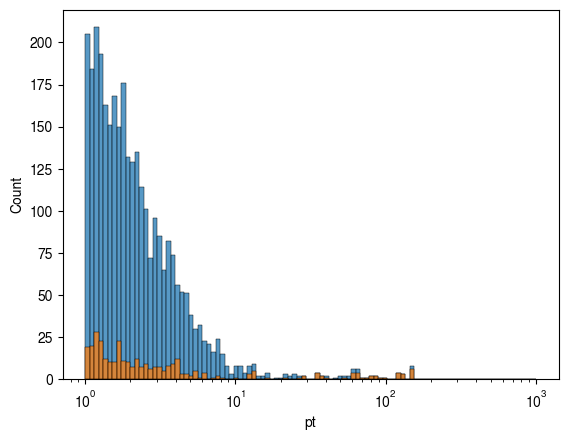

In [68]:
sns.histplot(edm_particles.pt, bins=100, binrange=(0, 3), log_scale=True)
sns.histplot(particles_df.pt, bins=100, binrange=(0, 3), log_scale=True)


In [69]:
edm_particles.columns

Index(['PDG', 'generatorStatus', 'simulatorStatus', 'charge', 'time', 'mass',
       'vx', 'vy', 'vz', 'px', 'py', 'pz', 'endpoint_x', 'endpoint_y',
       'endpoint_z', 'parents_begin', 'parents_end', 'daughters_begin',
       'daughters_end', 'pt', 'p', 'eta', 'phi'],
      dtype='object')

In [70]:
edm_particles

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_y,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi
0,2212,4,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,0.000000,...,-0.005813,-105.372111,0,0,0,15,0.000000,7000.000000,inf,0.000000
1,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,2.672720,...,-0.005813,-105.372111,0,1,15,16,2.682210,2607.457764,7.572637,-0.084146
2,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.115590,...,-0.005813,-105.372111,1,2,16,17,0.498858,376.885193,7.320521,-1.804631
3,21,61,0,0.000000,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.391733,...,-0.005813,-105.372111,2,3,17,18,1.721345,267.841492,5.740426,-1.800382
4,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,3.310610,...,-0.005813,-105.372111,3,4,18,19,3.345098,155.382065,4.531422,0.143721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406500,11,0,1493172224,-1.000000,19.541965,0.000511,-299.902636,1145.078819,2991.900520,-0.000953,...,1141.891321,2995.630804,425960,425961,425965,425965,0.002750,0.004253,1.002901,-1.924785
406501,11,0,1493172224,-1.000000,24.605585,0.000511,-821.447430,-263.918514,3208.522889,-0.000823,...,-265.622790,3208.615996,425961,425962,425965,425965,0.003097,0.003221,0.281592,-1.839849
406502,11,0,1493172224,-1.000000,20.544994,0.000511,-485.961906,1084.170673,3200.297544,-0.000461,...,1084.139483,3200.321416,425962,425963,425965,425965,0.001174,0.001435,0.655716,-1.974886
406503,11,0,1493172224,-1.000000,20.208435,0.000511,-223.787133,1091.063616,3215.822788,0.000249,...,1091.005626,3215.876509,425963,425964,425965,425965,0.001502,0.002022,0.809731,-1.404139


In [71]:
particles_df

,event_id,particle_id,particle_type,process,vx,vy,vz,vt,px,py,...,vertex_secondary,particle,generation,sub_particle,e_loss,total_x0,total_l0,number_of_hits,outcome,n_hits
0,0,4504699155841029,-2,0,0.003543,-0.005813,-105.372108,2425.787842,-3.244334,1.407285,...,1,1,1,5,12.115084,0.0,0.0,0,0,0.0
1,0,4504699155841032,-1,0,0.003543,-0.005813,-105.372108,2425.787842,-2.774586,-0.292908,...,1,1,1,8,12.869830,0.0,0.0,0,0,0.0
2,0,4542082569470722,-211,0,0.003543,-0.005813,-105.372108,2425.787842,1.175650,0.272212,...,35,2,24,770,2.083743,0.0,0.0,0,0,13.0
3,0,4592660372048331,211,0,0.009781,0.014497,-116.807983,3995.353760,-0.969926,-0.885298,...,81,18,12,51659,5.592474,0.0,0.0,0,0,10.0
4,0,4621247405833537,3,0,0.003543,-0.005813,-105.372108,2425.787842,-1.653649,-0.264909,...,107,2,11,15681,1.554827,0.0,0.0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323,0,8988507592132378,-2212,0,0.003543,-0.005813,-105.372108,2425.787842,3.789078,-0.840354,...,4079,2,23,1818,37.361057,0.0,0.0,0,0,2.0
324,0,8988507592132379,213,0,0.003543,-0.005813,-105.372108,2425.787842,6.949781,-1.863585,...,4079,2,23,1819,68.278442,0.0,0.0,0,0,0.0
325,0,8989607103824618,11,0,0.643046,-0.055682,-106.382172,2427.019775,3.200787,-0.905479,...,4080,2,24,746,7.821862,0.0,0.0,0,0,16.0
326,0,9001701731864898,-321,0,1.826368,0.111195,-107.663475,2428.814453,3.066757,0.326555,...,4091,2,26,4418,4.048696,0.0,0.0,0,0,15.0


## Performance metrics

1. How many target particles are there?

In [101]:
conditions = [
    "pt > 1",
    "abs(particle_type) != 11",
    "n_hits >= 9",
    "abs(eta) < 3.0"
]

target_particles = particles_df.query(" and ".join(conditions))

print(f"Total particles: {len(particles_df)}")
print(f"Target particles: {len(target_particles)}")


Total particles: 328
Target particles: 107


In [73]:
target_particles

,event_id,particle_id,particle_type,process,vx,vy,vz,vt,px,py,...,vertex_secondary,particle,generation,sub_particle,e_loss,total_x0,total_l0,number_of_hits,outcome,n_hits
2,0,4542082569470722,-211,0,0.003543,-0.005813,-105.372108,2425.787842,1.175650,0.272212,...,35,2,24,770,2.083743,0.0,0.0,0,0,13.0
3,0,4592660372048331,211,0,0.009781,0.014497,-116.807983,3995.353760,-0.969926,-0.885298,...,81,18,12,51659,5.592474,0.0,0.0,0,0,10.0
11,0,4672924754352279,2212,0,0.017884,0.000470,-2.547834,-1078.258057,0.444821,1.345555,...,154,20,11,39063,5.034874,0.0,0.0,0,0,10.0
12,0,4672924754352280,211,0,0.017884,0.000470,-2.547834,-1078.258057,-0.698999,0.795631,...,154,20,11,39064,7.730437,0.0,0.0,0,0,12.0
13,0,4672924754352283,211,0,0.017884,0.000470,-2.547834,-1078.258057,-0.369829,1.730302,...,154,20,11,39067,9.408726,0.0,0.0,0,0,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
312,0,8860964242195789,321,0,0.003543,-0.005813,-105.372108,2425.787842,-0.809142,-1.976608,...,3963,2,6,1357,1.864444,0.0,0.0,0,0,11.0
315,0,8902745751029190,321,0,0.001655,0.006170,-11.768105,-707.995056,-1.196746,0.152835,...,4001,6,4,1478,8.257464,0.0,0.0,0,0,11.0
322,0,8988507592132373,211,0,0.003543,-0.005813,-105.372108,2425.787842,0.550834,1.506059,...,4079,2,23,1813,3.422851,0.0,0.0,0,0,12.0
326,0,9001701731864898,-321,0,1.826368,0.111195,-107.663475,2428.814453,3.066757,0.326555,...,4091,2,26,4418,4.048696,0.0,0.0,0,0,15.0


### CKF Tracks

In [74]:
ckf_tracks_file = "/global/cfs/projectdirs/m3443/usr/dtmurnane/Side_Work/ACTS/outputs/low_pileup_pilot/gg2ttbar/v1/runs/0/event000000000-tracks_ckf.csv"
ambi_tracks_file = "/global/cfs/projectdirs/m3443/usr/dtmurnane/Side_Work/ACTS/outputs/low_pileup_pilot/gg2ttbar/v1/runs/0/event000000000-tracks_ambi.csv"

ckf_tracks = pd.read_csv(ckf_tracks_file)
ambi_tracks = pd.read_csv(ambi_tracks_file)

ckf_tracks.columns, ambi_tracks.columns


(Index(['track_id', 'seed_id', 'particleId', 'nStates', 'nMajorityHits',
        'nMeasurements', 'nOutliers', 'nHoles', 'nSharedHits', 'chi2', 'ndf',
        'chi2/ndf', 'pT', 'eta', 'phi', 'truthMatchProbability',
        'good/duplicate/fake', 'Hits_ID'],
       dtype='object'),
 Index(['track_id', 'seed_id', 'particleId', 'nStates', 'nMajorityHits',
        'nMeasurements', 'nOutliers', 'nHoles', 'nSharedHits', 'chi2', 'ndf',
        'chi2/ndf', 'pT', 'eta', 'phi', 'truthMatchProbability',
        'good/duplicate/fake', 'Hits_ID'],
       dtype='object'))

In [102]:
ckf_tracks = ckf_tracks[ckf_tracks["good/duplicate/fake"] == "good"]
ambi_tracks = ambi_tracks[ambi_tracks["good/duplicate/fake"] == "good"]

In [103]:
def parse_hits_string(hits_str):
    # Remove the brackets and trailing comma if present
    hits_str = hits_str.strip('[]')
    # Split by comma and filter out empty strings
    hits = [int(x) for x in hits_str.split(',') if x.strip()]
    return hits

In [104]:
def get_majority_particle_info(hits):
    # hits is a list of hit_ids
    hits = parse_hits_string(hits)
    hit_particles = hits_df.particle_id[hits]
    mode_result = hit_particles.mode()
    majority_particle = mode_result[0]
    num_majority_hits = (hit_particles == majority_particle).sum()
    return pd.Series({
        'majority_particle': majority_particle,
        'num_majority_hits': num_majority_hits
    })

# Apply the function and expand the results into separate columns
majority_info = ckf_tracks["Hits_ID"].apply(get_majority_particle_info)
ckf_tracks[['majority_particle', 'num_track_majority_hits']] = majority_info

majority_info = ambi_tracks["Hits_ID"].apply(get_majority_particle_info)
ambi_tracks[['majority_particle', 'num_track_majority_hits']] = majority_info

ckf_tracks = ckf_tracks.merge(particles_df[["particle_id", "n_hits"]], left_on="majority_particle", right_on="particle_id", how="left").rename(columns={"n_hits": "num_particle_majority_hits"})
ambi_tracks = ambi_tracks.merge(particles_df[["particle_id", "n_hits"]], left_on="majority_particle", right_on="particle_id", how="left").rename(columns={"n_hits": "num_particle_majority_hits"})

In [105]:
ckf_tracks

,track_id,seed_id,particleId,nStates,nMajorityHits,nMeasurements,nOutliers,nHoles,nSharedHits,chi2,...,good/duplicate/fake,Hits_ID,majority_particle,num_track_majority_hits,particle_id_x,num_particle_majority_hits,purity,efficiency,particle_id_y,num_particle_majority_hits
0,179,4802,1|3650|2|16|51795,20,11,11,0,0,0,25.4912,...,good,"[2831,2911,3260,4286,4298,5133,5145,10336,1164...",8516817103407699,11,8.516817e+15,18.0,1.0,0.611111,8.516817e+15,18.0
1,175,4800,1|4001|6|4|1478,24,11,11,0,0,0,27.7405,...,good,"[2871,3252,5637,5962,6567,6903,7237,14930,1530...",8902745751029190,11,8.902746e+15,11.0,1.0,1.000000,8.902746e+15,11.0
2,174,4753,1|1973|18|9|33789,25,12,12,0,0,0,24.8063,...,good,"[2808,2877,1566,1361,1262,1018,750,9414,9148,8...",6672936371586045,12,6.672936e+15,12.0,1.0,1.000000,6.672936e+15,12.0
3,173,4744,1|303|10|15|48253,28,16,16,0,0,0,23.7577,...,good,"[2912,3257,4294,5152,10420,10354,11694,11676,1...",4836751819390077,16,4.836752e+15,18.0,1.0,0.888889,4.836752e+15,18.0
4,171,4732,1|2802|18|7|18686,26,13,13,0,0,0,34.7660,...,good,"[2914,3290,4295,4312,5153,5160,10397,11679,129...",7584431510866174,13,7.584432e+15,15.0,1.0,0.866667,7.584432e+15,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,119,3751,1|1024|2|11|16949,24,12,12,0,0,0,19.6395,...,good,"[2614,3967,4103,4942,10033,11394,12602,13584,1...",5629499568505397,12,5.629500e+15,12.0,1.0,1.000000,5.629500e+15,12.0
106,121,3796,1|1418|12|11|47449,27,15,15,0,0,0,18.0960,...,good,"[2633,3971,4102,4115,4965,10032,11393,12600,13...",6062707317651801,15,6.062707e+15,18.0,1.0,0.833333,6.062707e+15,18.0
107,123,3803,1|1032|2|12|32508,24,12,12,0,0,0,15.0611,...,good,"[2615,3962,4096,4964,10030,11392,12599,13595,1...",5638295661608700,12,5.638296e+15,12.0,1.0,1.000000,5.638296e+15,12.0
108,124,3815,1|154|20|11|39067,26,13,13,0,0,0,28.7485,...,good,"[2605,2674,3976,1667,1470,1241,9678,9393,9117,...",4672924754352283,13,4.672925e+15,13.0,1.0,1.000000,4.672925e+15,13.0


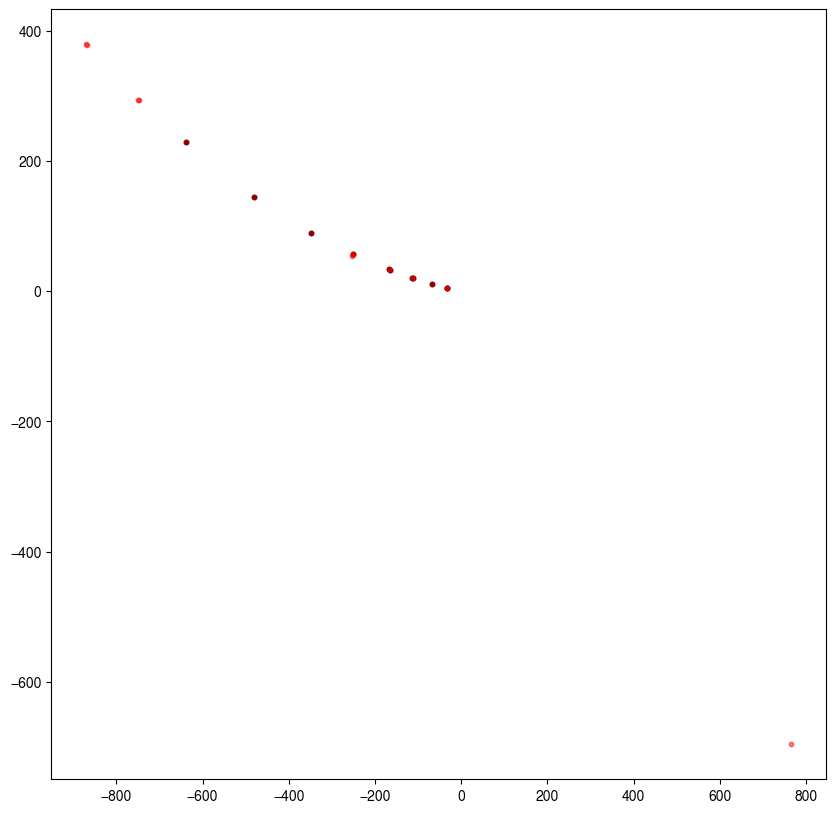

In [106]:
track_hits = parse_hits_string(ckf_tracks["Hits_ID"].iloc[0])

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

ax.scatter(hits_df.tx[track_hits], hits_df.ty[track_hits], s=10, c="k")

particle_hits = hits_df[hits_df.particle_id == ckf_tracks["majority_particle"].iloc[0]]
ax.scatter(particle_hits.tx, particle_hits.ty, s=10, c="r", alpha=0.5)


In [107]:
particle_hits

,event_id,geometry_id,particle_id,tx,ty,tz,tt,tpx,tpy,tpz,...,deltapx,deltapy,deltapz,deltae,index,volume_id,boundary_id,layer_id,approach_id,sensitive_id
entry,,,,,,,,,,,,,,,,,,,,,
2831,0,1224979236083777792,8516817103407699,-31.771582,5.041936,-39.474697,2499.383057,-1.057776,0.178189,2.198081,...,0.0,0.0,0.0,-0.000074,-1,17,0,2,0,193
2911,0,1224979236083781376,8516817103407699,-32.816330,5.219523,-37.305111,2501.806641,-1.059006,0.178541,2.197232,...,0.0,0.0,0.0,-0.000089,-1,17,0,2,0,207
3260,0,1224979373522710016,8516817103407699,-67.028313,11.321573,33.909664,2581.172607,-1.051913,0.198862,2.197494,...,0.0,0.0,0.0,-0.000129,-1,17,0,4,0,110
4286,0,1224979510961699584,8516817103407699,-111.713425,20.419338,127.562874,2685.508545,-1.044054,0.226033,2.195257,...,0.0,0.0,0.0,-0.000126,-1,17,0,6,0,251
4298,0,1224979510961703168,8516817103407699,-113.348587,20.773329,131.002167,2689.342285,-1.043651,0.226059,2.195184,...,0.0,0.0,0.0,-0.000081,-1,17,0,6,0,265
5133,0,1224979648400697088,8516817103407699,-166.181992,33.037300,242.310806,2813.363281,-1.037476,0.257712,2.192760,...,0.0,0.0,0.0,-0.000069,-1,17,0,8,0,423
5145,0,1224979648400700672,8516817103407699,-167.731140,33.425312,245.587006,2817.015625,-1.037235,0.259546,2.192434,...,0.0,0.0,0.0,-0.000089,-1,17,0,8,0,437
10334,0,1729382394349284864,8516817103407699,-252.571747,54.003387,424.166260,3021.852295,0.000698,-0.000352,-0.000077,...,0.0,0.0,0.0,-0.000085,-1,24,0,2,0,238
10335,0,1729382394349284864,8516817103407699,-251.723190,56.835419,424.044556,3015.876221,-0.000818,0.000361,0.000096,...,0.0,0.0,0.0,-0.000038,-1,24,0,2,0,238


In [108]:
# 2. Are these majority particles overlapping with the target particles?

num_tracks = len(ckf_tracks)
num_target_particles = len(target_particles)

num_reconstructed_target_particles = len(target_particles[target_particles["particle_id"].isin(ckf_tracks["majority_particle"].unique())])

print("CKF")
print(f"num_tracks: {num_tracks}, num_reconstructable_particles: {num_target_particles}, num_reconstructed_target_particles: {num_reconstructed_target_particles}")

CKF
num_tracks: 110, num_reconstructable_particles: 107, num_reconstructed_target_particles: 103


In [109]:
# 2. Are these majority particles overlapping with the target particles?

num_tracks = len(ambi_tracks)
num_target_particles = len(target_particles)

num_reconstructed_target_particles = len(target_particles[target_particles["particle_id"].isin(ambi_tracks["majority_particle"].unique())])
print("Ambi")
print(f"num_tracks: {num_tracks}, num_reconstructable_particles: {num_target_particles}, num_reconstructed_target_particles: {num_reconstructed_target_particles}")

Ambi
num_tracks: 110, num_reconstructable_particles: 107, num_reconstructed_target_particles: 103


In [110]:
ckf_tracks["purity"] = ckf_tracks["num_track_majority_hits"] / ckf_tracks["nMeasurements"]
ckf_tracks["efficiency"] = ckf_tracks["num_track_majority_hits"] / ckf_tracks["num_particle_majority_hits"]

TypeError: '<' not supported between instances of 'str' and 'int'

In [94]:
ckf_tracks

,track_id,seed_id,particleId,nStates,nMajorityHits,nMeasurements,nOutliers,nHoles,nSharedHits,chi2,...,phi,truthMatchProbability,good/duplicate/fake,Hits_ID,majority_particle,num_track_majority_hits,particle_id,num_particle_majority_hits,purity,efficiency
0,179,4802,1|3650|2|16|51795,20,11,11,0,0,0,25.4912,...,2.99523,1.0,good,"[2831,2911,3260,4286,4298,5133,5145,10336,1164...",8516817103407699,11,8.516817e+15,18.0,1.0,0.611111
1,175,4800,1|4001|6|4|1478,24,11,11,0,0,0,27.7405,...,3.01822,1.0,good,"[2871,3252,5637,5962,6567,6903,7237,14930,1530...",8902745751029190,11,8.902746e+15,11.0,1.0,1.000000
2,174,4753,1|1973|18|9|33789,25,12,12,0,0,0,24.8063,...,2.99736,1.0,good,"[2808,2877,1566,1361,1262,1018,750,9414,9148,8...",6672936371586045,12,6.672936e+15,12.0,1.0,1.000000
3,173,4744,1|303|10|15|48253,28,16,16,0,0,0,23.7577,...,3.00063,1.0,good,"[2912,3257,4294,5152,10420,10354,11694,11676,1...",4836751819390077,16,4.836752e+15,18.0,1.0,0.888889
4,171,4732,1|2802|18|7|18686,26,13,13,0,0,0,34.7660,...,3.07485,1.0,good,"[2914,3290,4295,4312,5153,5160,10397,11679,129...",7584431510866174,13,7.584432e+15,15.0,1.0,0.866667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,119,3751,1|1024|2|11|16949,24,12,12,0,0,0,19.6395,...,1.58463,1.0,good,"[2614,3967,4103,4942,10033,11394,12602,13584,1...",5629499568505397,12,5.629500e+15,12.0,1.0,1.000000
106,121,3796,1|1418|12|11|47449,27,15,15,0,0,0,18.0960,...,1.66262,1.0,good,"[2633,3971,4102,4115,4965,10032,11393,12600,13...",6062707317651801,15,6.062707e+15,18.0,1.0,0.833333
107,123,3803,1|1032|2|12|32508,24,12,12,0,0,0,15.0611,...,1.61065,1.0,good,"[2615,3962,4096,4964,10030,11392,12599,13595,1...",5638295661608700,12,5.638296e+15,12.0,1.0,1.000000
108,124,3815,1|154|20|11|39067,26,13,13,0,0,0,28.7485,...,1.78061,1.0,good,"[2605,2674,3976,1667,1470,1241,9678,9393,9117,...",4672924754352283,13,4.672925e+15,13.0,1.0,1.000000


In [91]:
reconstructed_tracks = ckf_tracks[(ckf_tracks["purity"] > 0.5) & (ckf_tracks["efficiency"] > 0.5)]

reconstructed_tracks

,track_id,seed_id,particleId,nStates,nMajorityHits,nMeasurements,nOutliers,nHoles,nSharedHits,chi2,...,phi,truthMatchProbability,good/duplicate/fake,Hits_ID,majority_particle,num_track_majority_hits,particle_id,num_particle_majority_hits,purity,efficiency
0,179,4802,1|3650|2|16|51795,20,11,11,0,0,0,25.4912,...,2.99523,1.0,good,"[2831,2911,3260,4286,4298,5133,5145,10336,1164...",8516817103407699,11,8.516817e+15,18.0,1.0,0.611111
1,175,4800,1|4001|6|4|1478,24,11,11,0,0,0,27.7405,...,3.01822,1.0,good,"[2871,3252,5637,5962,6567,6903,7237,14930,1530...",8902745751029190,11,8.902746e+15,11.0,1.0,1.000000
2,174,4753,1|1973|18|9|33789,25,12,12,0,0,0,24.8063,...,2.99736,1.0,good,"[2808,2877,1566,1361,1262,1018,750,9414,9148,8...",6672936371586045,12,6.672936e+15,12.0,1.0,1.000000
3,173,4744,1|303|10|15|48253,28,16,16,0,0,0,23.7577,...,3.00063,1.0,good,"[2912,3257,4294,5152,10420,10354,11694,11676,1...",4836751819390077,16,4.836752e+15,18.0,1.0,0.888889
4,171,4732,1|2802|18|7|18686,26,13,13,0,0,0,34.7660,...,3.07485,1.0,good,"[2914,3290,4295,4312,5153,5160,10397,11679,129...",7584431510866174,13,7.584432e+15,15.0,1.0,0.866667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,119,3751,1|1024|2|11|16949,24,12,12,0,0,0,19.6395,...,1.58463,1.0,good,"[2614,3967,4103,4942,10033,11394,12602,13584,1...",5629499568505397,12,5.629500e+15,12.0,1.0,1.000000
106,121,3796,1|1418|12|11|47449,27,15,15,0,0,0,18.0960,...,1.66262,1.0,good,"[2633,3971,4102,4115,4965,10032,11393,12600,13...",6062707317651801,15,6.062707e+15,18.0,1.0,0.833333
107,123,3803,1|1032|2|12|32508,24,12,12,0,0,0,15.0611,...,1.61065,1.0,good,"[2615,3962,4096,4964,10030,11392,12599,13595,1...",5638295661608700,12,5.638296e+15,12.0,1.0,1.000000
108,124,3815,1|154|20|11|39067,26,13,13,0,0,0,28.7485,...,1.78061,1.0,good,"[2605,2674,3976,1667,1470,1241,9678,9393,9117,...",4672924754352283,13,4.672925e+15,13.0,1.0,1.000000


In [111]:
num_reconstructed_target_particles = target_particles["particle_id"].isin(reconstructed_tracks["majority_particle"]).sum()

In [112]:
target_particles["particle_id"].isin(ckf_tracks["majority_particle"]).sum()

103

In [113]:
num_reconstructed_target_particles

103

In [114]:
print(f"Tracking efficiency: {num_reconstructed_target_particles / num_target_particles}")

Tracking efficiency: 0.9626168224299065


In [83]:
from matplotlib import animation
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def create_particle_track_gif(particle_hits_df, track_hits_df, output_file='particle_track.gif', fps=3):
    """
    Create a GIF of particle hits appearing in 3D space, followed by track hits, with hit numbers
    """
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Sort hits by time if available
    if 'tt' in particle_hits_df.columns:
        particle_hits_sorted = particle_hits_df.sort_values('tt')
    else:
        particle_hits_sorted = particle_hits_df
        
    # Initialize empty scatter plots and text annotations
    particle_scatter = ax.scatter([], [], [], c='blue', marker='o', label='Particle Hits', s=10)
    track_scatter = ax.scatter([], [], [], c='red', marker='x', label='Track Hits', s=20)
    
    # Initialize text collections for hit numbers
    particle_texts = []
    track_texts = []
    
    # Calculate combined limits and offset
    all_hits = pd.concat([particle_hits_df, track_hits_df])
    x_range = all_hits.tx.max() - all_hits.tx.min()
    y_range = all_hits.ty.max() - all_hits.ty.min()
    z_range = all_hits.tz.max() - all_hits.tz.min()
    text_offset = min(x_range, y_range, z_range) * 0.05
    
    # Set axis labels and limits
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    
    ax.set_xlim([all_hits.tx.min(), all_hits.tx.max()])
    ax.set_ylim([all_hits.ty.min(), all_hits.ty.max()])
    ax.set_zlim([all_hits.tz.min(), all_hits.tz.max()])
    
    ax.legend()
    
    def init():
        # Clear all texts
        for txt in particle_texts:
            txt.remove()
        particle_texts.clear()
        for txt in track_texts:
            txt.remove()
        track_texts.clear()
            
        particle_scatter._offsets3d = ([], [], [])
        track_scatter._offsets3d = ([], [], [])
        return particle_scatter, track_scatter
    
    def animate(frame):
        # Clear previous text annotations
        for txt in particle_texts:
            txt.remove()
        particle_texts.clear()
        for txt in track_texts:
            txt.remove()
        track_texts.clear()
        
        if frame < len(particle_hits_sorted):
            # First phase: Show particle hits appearing one by one
            points = particle_hits_sorted.iloc[:frame+1]
            particle_scatter._offsets3d = (points.tx, points.ty, points.tz)
            track_scatter._offsets3d = ([], [], [])
            
            # Add hit numbers for particle hits (above points)
            for idx, (x, y, z) in enumerate(zip(points.tx, points.ty, points.tz)):
                txt = ax.text(x, y, z + text_offset, f'{idx+1}', fontsize=8)
                particle_texts.append(txt)
                
        else:
            # Second phase: Keep all particle hits and add track hits
            particle_scatter._offsets3d = (particle_hits_sorted.tx, 
                                         particle_hits_sorted.ty, 
                                         particle_hits_sorted.tz)
            
            # Add hit numbers for all particle hits (above points)
            for idx, (x, y, z) in enumerate(zip(particle_hits_sorted.tx, 
                                              particle_hits_sorted.ty, 
                                              particle_hits_sorted.tz)):
                txt = ax.text(x, y, z + text_offset, f'{idx+1}', fontsize=8)
                particle_texts.append(txt)
            
            # Add track hits one by one
            track_frame = frame - len(particle_hits_sorted)
            if track_frame < len(track_hits_df):
                track_points = track_hits_df.iloc[:track_frame+1]
                track_scatter._offsets3d = (track_points.tx, 
                                          track_points.ty, 
                                          track_points.tz)
                
                # Add hit numbers for track hits (bottom left of points)
                for idx, (x, y, z) in enumerate(zip(track_points.tx, 
                                                  track_points.ty, 
                                                  track_points.tz)):
                    txt = ax.text(x - text_offset, y - text_offset, z - text_offset, 
                                f'{idx+1}', color='red', fontsize=8)
                    track_texts.append(txt)
            
        return particle_scatter, track_scatter
    
    # Total number of frames is sum of both particle and track hits
    total_frames = len(particle_hits_sorted) + len(track_hits_df)
    
    # Create animation
    anim = animation.FuncAnimation(fig, animate, init_func=init,
                                 frames=total_frames, interval=1000//fps,
                                 blit=False)  # blit must be False for text updates
    
    # Save as GIF
    anim.save(output_file, writer='pillow')
    plt.close()

# Example usage
particle_id = ckf_tracks["majority_particle"].iloc[0]
particle_hits = hits_df[hits_df.particle_id == particle_id].copy()

# Get track hits
track_hits_indices = parse_hits_string(ckf_tracks["Hits_ID"].iloc[0])
track_hits = hits_df.iloc[track_hits_indices].copy()

create_particle_track_gif(particle_hits, track_hits, 'particle_track.gif', fps=3)